In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("dataset.csv")

In [3]:
df.head(10)

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium
5,6,28,20.2,124,78,203,84,Never,5036,5,0.0,5.2,No,8,2.9,0.0,Low
6,7,20,29.0,139,86,208,78,Never,2172,4,2.7,8.2,No,5,9.9,8.7,Low
7,8,44,24.7,146,104,220,74,Former,4840,8,1.8,7.6,No,6,2.6,30.9,Medium
8,9,48,26.1,136,87,221,75,Former,1366,8,0.0,6.0,No,6,3.0,31.3,Medium
9,10,89,32.7,162,107,286,74,Never,2443,2,1.9,7.1,No,5,4.4,58.8,High


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        5500 non-null   int64  
 1   age                               5500 non-null   int64  
 2   bmi                               5500 non-null   float64
 3   systolic_bp                       5500 non-null   int64  
 4   diastolic_bp                      5500 non-null   int64  
 5   cholesterol_mg_dl                 5500 non-null   int64  
 6   resting_heart_rate                5500 non-null   int64  
 7   smoking_status                    5500 non-null   str    
 8   daily_steps                       5500 non-null   int64  
 9   stress_level                      5500 non-null   int64  
 10  physical_activity_hours_per_week  5500 non-null   float64
 11  sleep_hours                       5500 non-null   float64
 12  family_history_he

In [5]:
df.nunique()

Patient_ID                          5500
age                                   73
bmi                                  232
systolic_bp                           82
diastolic_bp                          55
cholesterol_mg_dl                    166
resting_heart_rate                    41
smoking_status                         3
daily_steps                         4211
stress_level                          10
physical_activity_hours_per_week     123
sleep_hours                           61
family_history_heart_disease           2
diet_quality_score                    10
alcohol_units_per_week               196
heart_disease_risk_score             921
risk_category                          3
dtype: int64

In [6]:
df.isnull().sum()

Patient_ID                          0
age                                 0
bmi                                 0
systolic_bp                         0
diastolic_bp                        0
cholesterol_mg_dl                   0
resting_heart_rate                  0
smoking_status                      0
daily_steps                         0
stress_level                        0
physical_activity_hours_per_week    0
sleep_hours                         0
family_history_heart_disease        0
diet_quality_score                  0
alcohol_units_per_week              0
heart_disease_risk_score            0
risk_category                       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score
count,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000
mean,2750.500000,53.872000,28.170818,147.248182,95.756727,239.684182,74.075091,5902.929455,4.907091,3.299364,6.869364,5.162909,3.782200,37.540455
std,1587.857571,21.196017,4.189877,13.222701,9.451559,28.570177,6.392166,3041.084590,2.298173,2.672457,1.091263,2.286134,3.515594,24.287026
min,1.000000,18.000000,15.000000,108.000000,64.000000,147.000000,48.000000,500.000000,1.000000,0.000000,4.000000,1.000000,0.000000,0.000000
25%,1375.750000,36.000000,25.200000,138.000000,89.000000,220.000000,70.000000,3428.000000,3.000000,1.200000,6.200000,3.000000,1.200000,18.400000
50%,2750.500000,54.000000,28.400000,147.000000,96.000000,240.000000,74.000000,5460.000000,5.000000,2.600000,6.900000,5.000000,2.800000,36.700000
75%,4125.250000,72.000000,31.100000,156.000000,102.000000,260.000000,79.000000,7772.000000,7.000000,4.900000,7.600000,7.000000,5.300000,55.500000
max,5500.000000,90.000000,40.900000,192.000000,120.000000,331.000000,92.000000,16793.000000,10.000000,12.900000,10.000000,10.000000,29.200000,100.000000


In [10]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1    

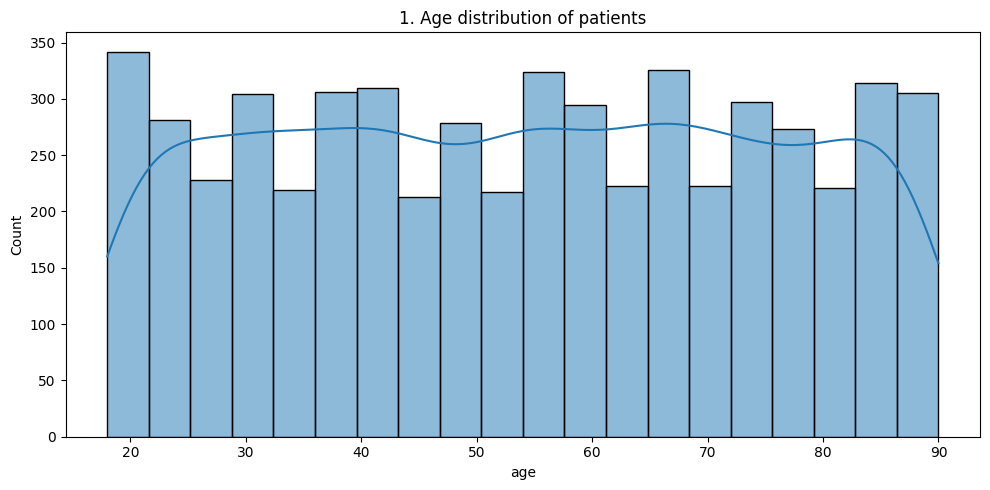

In [11]:
fig = plt.figure(figsize=(10,5))
sns.histplot(df['age'], bins= 20, kde=True)
plt.title(f'{plot_no}. Age distribution of patients')
show_fig()
plot_no += 1

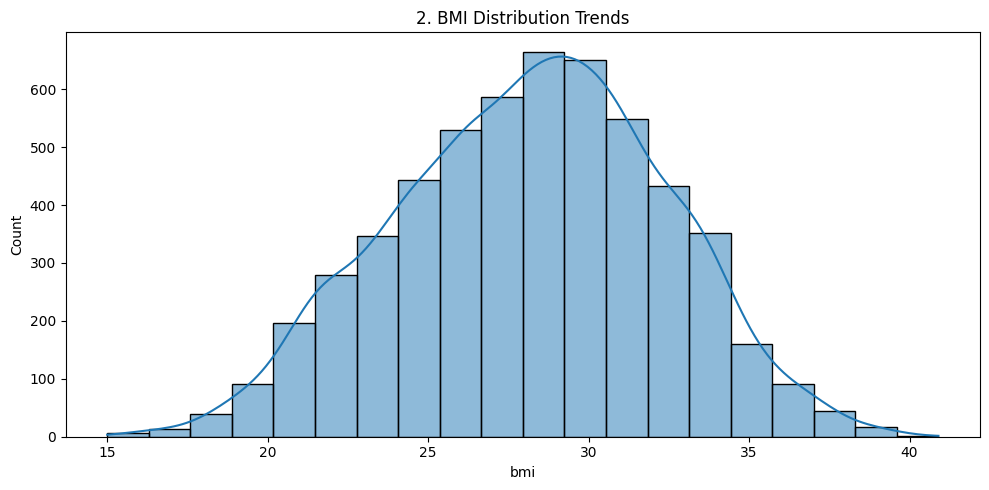

In [12]:
fig = plt.figure(figsize=(10,5))
sns.histplot(df['bmi'], bins=20, kde=True)
plt.title(f'{plot_no}. BMI Distribution Trends')
show_fig()
plot_no += 1

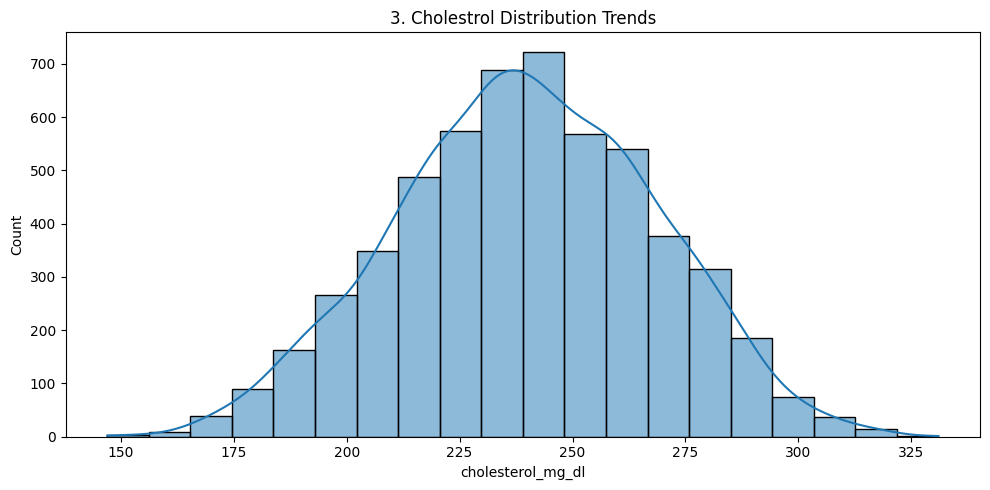

In [13]:
fig = plt.figure(figsize=(10,5))
sns.histplot(df['cholesterol_mg_dl'], bins=20, kde=True)
plt.title(f'{plot_no}. Cholestrol Distribution Trends')
show_fig()
plot_no += 1

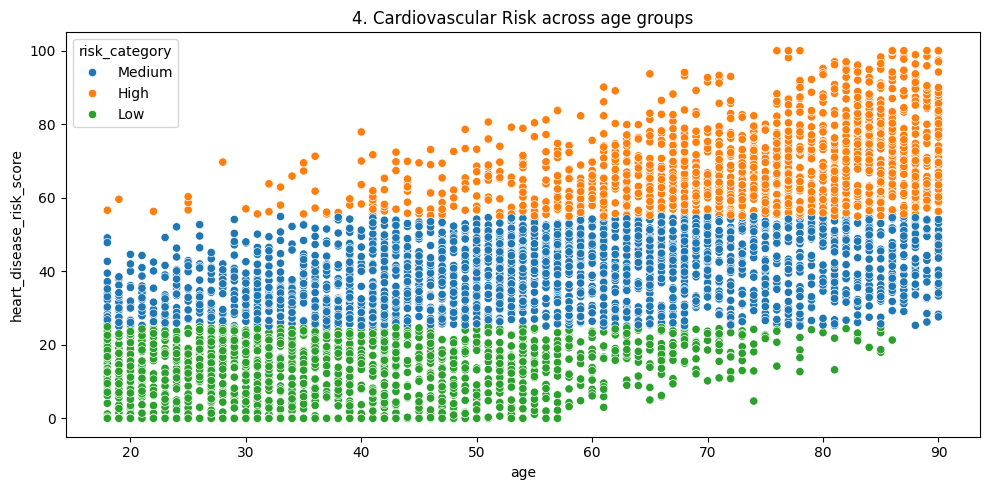

In [14]:
fig = plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='age', y='heart_disease_risk_score', hue='risk_category')
plt.title(f'{plot_no}. Cardiovascular Risk across age groups')
show_fig()
plot_no += 1

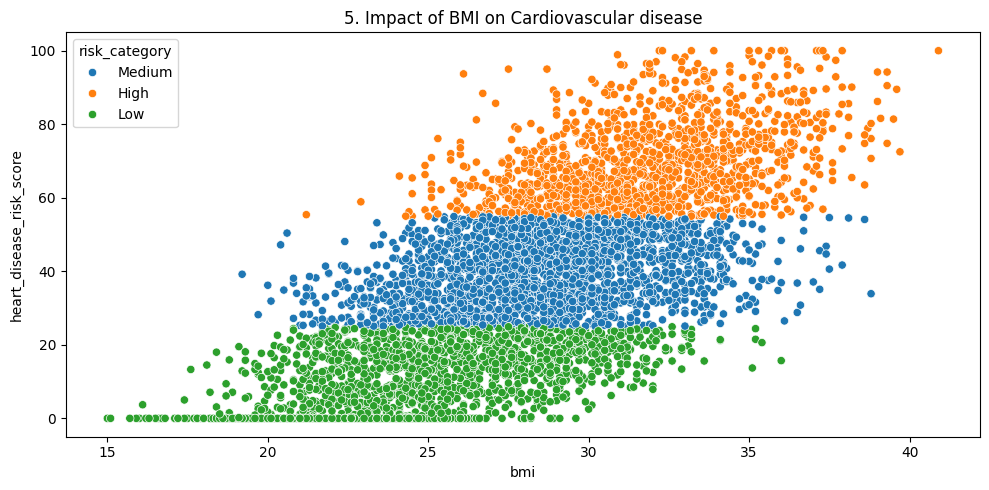

In [15]:
fig = plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='bmi', y='heart_disease_risk_score', hue='risk_category')
plt.title(f'{plot_no}. Impact of BMI on Cardiovascular disease')
show_fig()
plot_no += 1

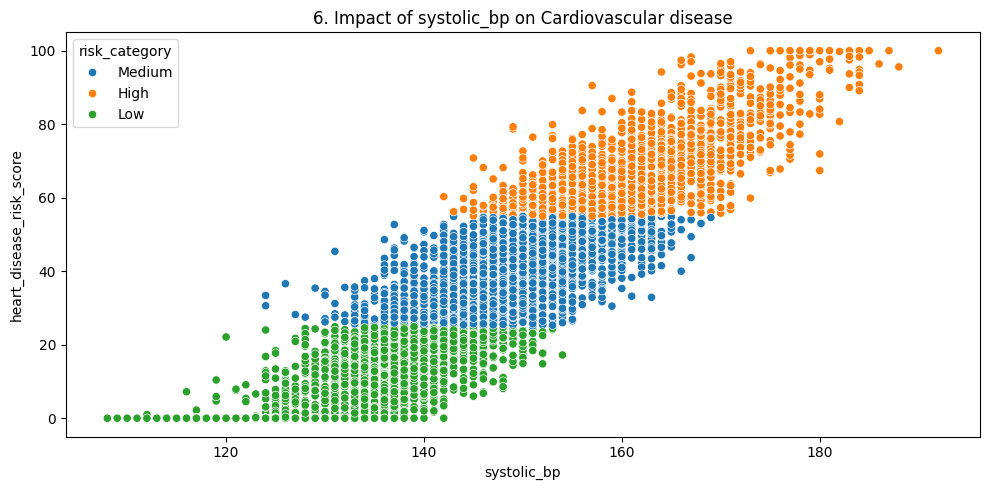

In [16]:
fig = plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='systolic_bp', y='heart_disease_risk_score', hue='risk_category')
plt.title(f'{plot_no}. Impact of systolic_bp on Cardiovascular disease')
show_fig()
plot_no += 1

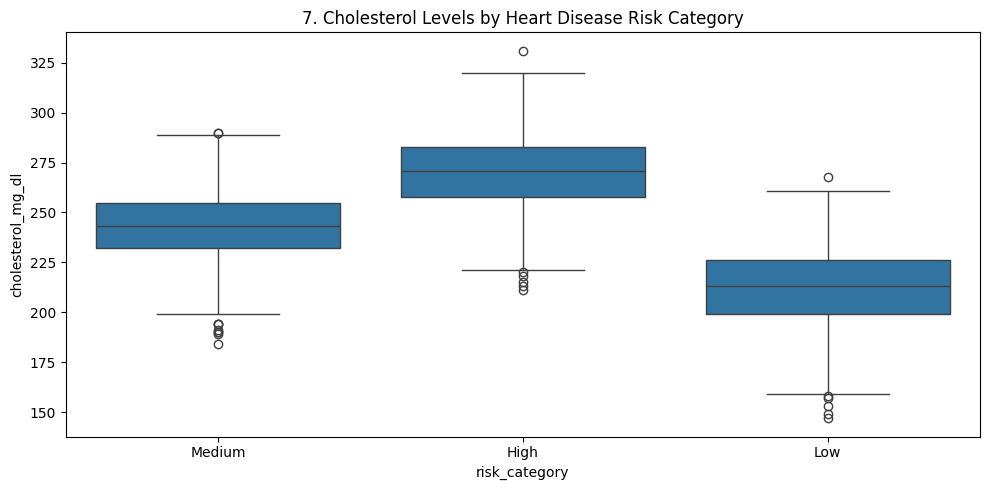

In [17]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='risk_category', y='cholesterol_mg_dl')
plt.title(f'{plot_no}. Cholesterol Levels by Heart Disease Risk Category')
show_fig()
plot_no += 1

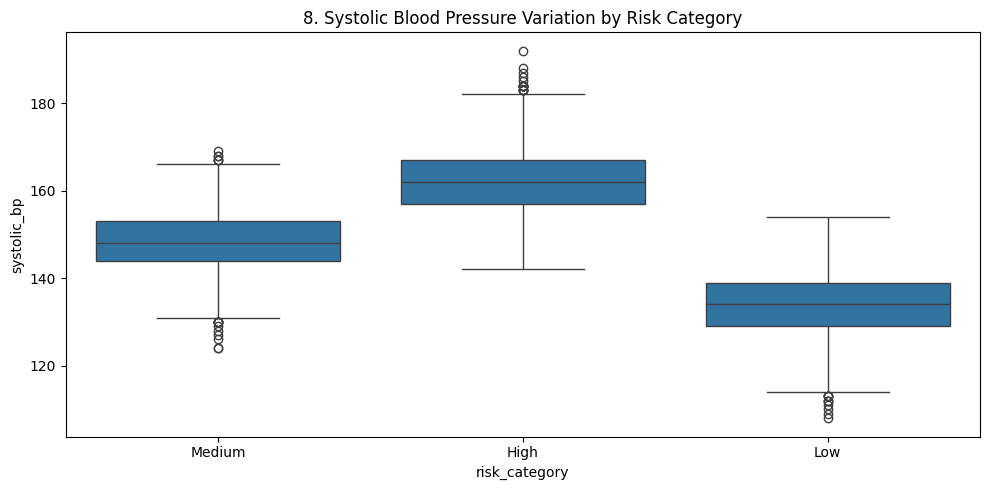

In [18]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='risk_category', y='systolic_bp')
plt.title(f'{plot_no}. Systolic Blood Pressure Variation by Risk Category')
show_fig()
plot_no += 1


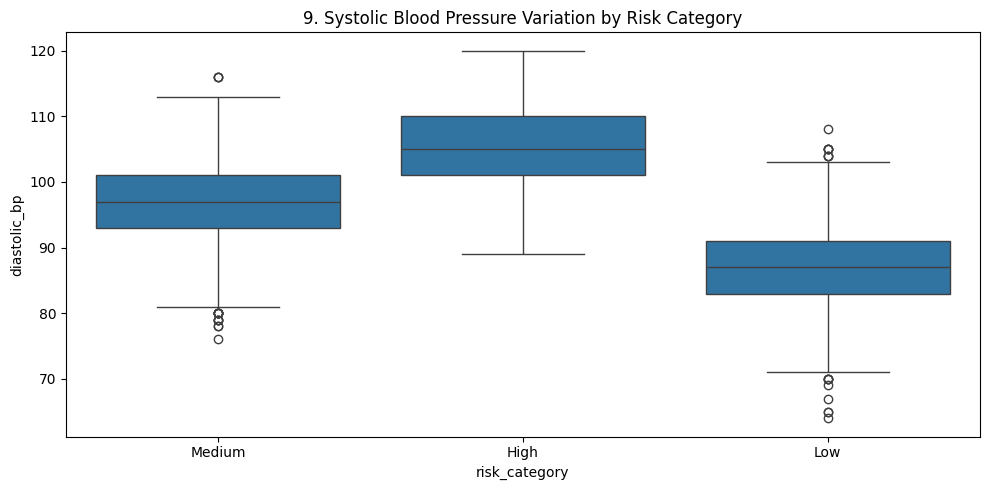

In [19]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='risk_category', y='diastolic_bp')
plt.title(f'{plot_no}. Systolic Blood Pressure Variation by Risk Category')
show_fig()
plot_no += 1


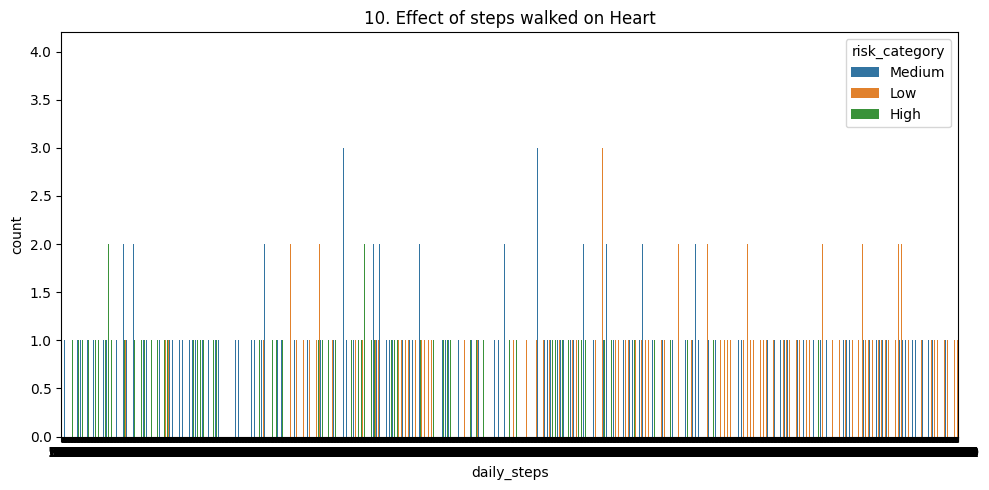

In [20]:
fig = plt.figure(figsize=(10,5))
sns.countplot(data=df, x='daily_steps', hue='risk_category')
plt.title(f'{plot_no}. Effect of steps walked on Heart')
show_fig()
plot_no += 1


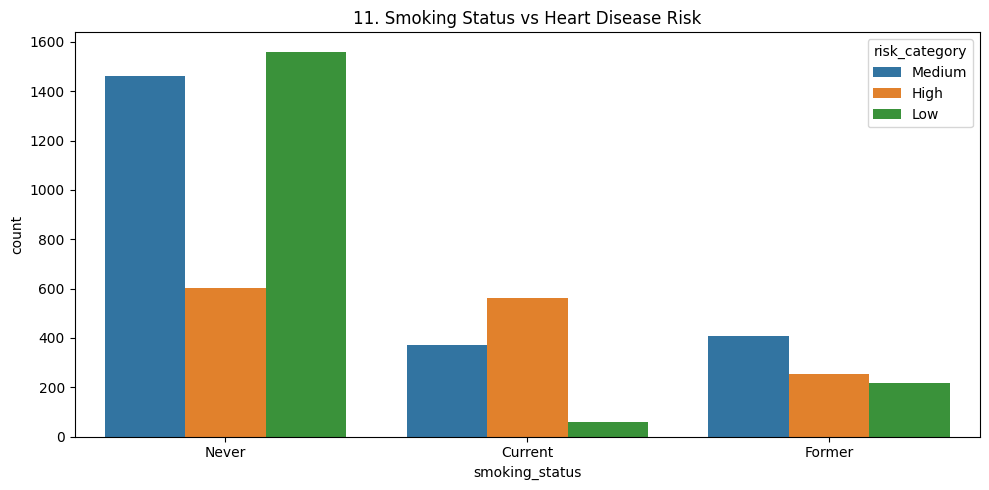

In [21]:
fig = plt.figure(figsize=(10,5))
sns.countplot(data=df, x='smoking_status', hue='risk_category')
plt.title(f'{plot_no}. Smoking Status vs Heart Disease Risk')
show_fig()
plot_no += 1

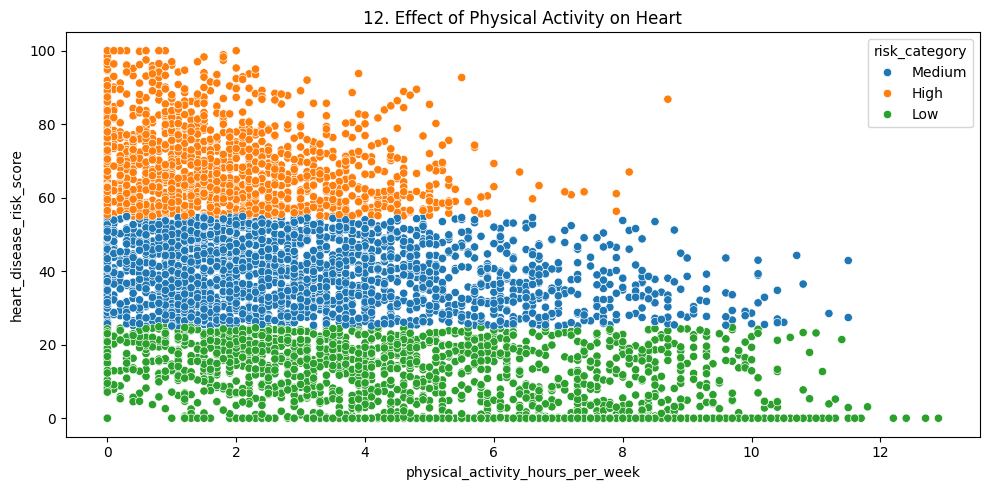

In [22]:
fig = plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='physical_activity_hours_per_week', y='heart_disease_risk_score', hue='risk_category')
plt.title(f'{plot_no}. Effect of Physical Activity on Heart')
show_fig()
plot_no += 1

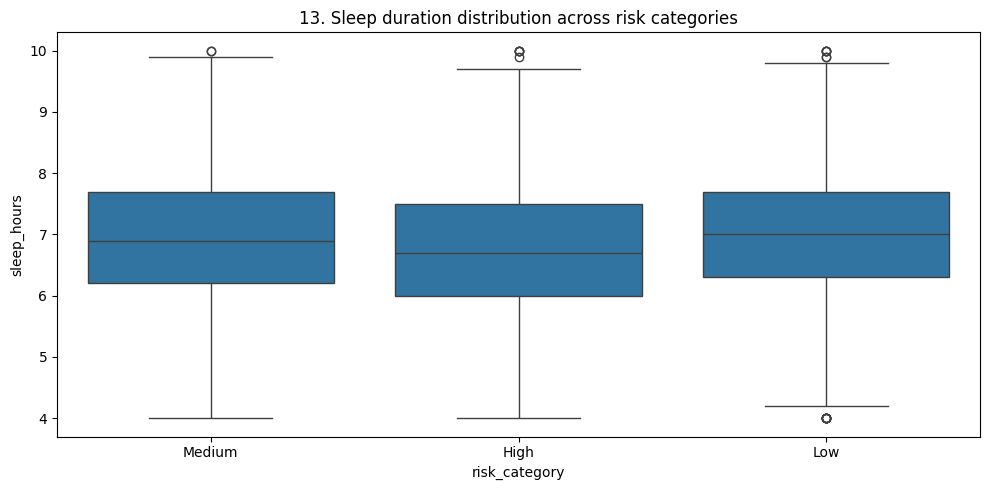

In [23]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='risk_category', y='sleep_hours')
plt.title(f'{plot_no}. Sleep duration distribution across risk categories')
show_fig()
plot_no += 1

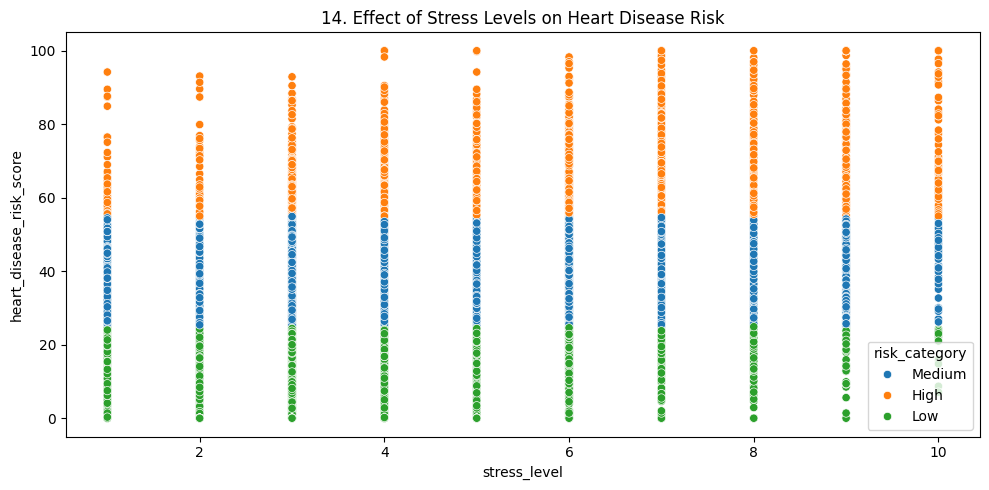

In [24]:
fig = plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='stress_level', y='heart_disease_risk_score', hue='risk_category')
plt.title(f'{plot_no}. Effect of Stress Levels on Heart Disease Risk')
show_fig()
plot_no += 1

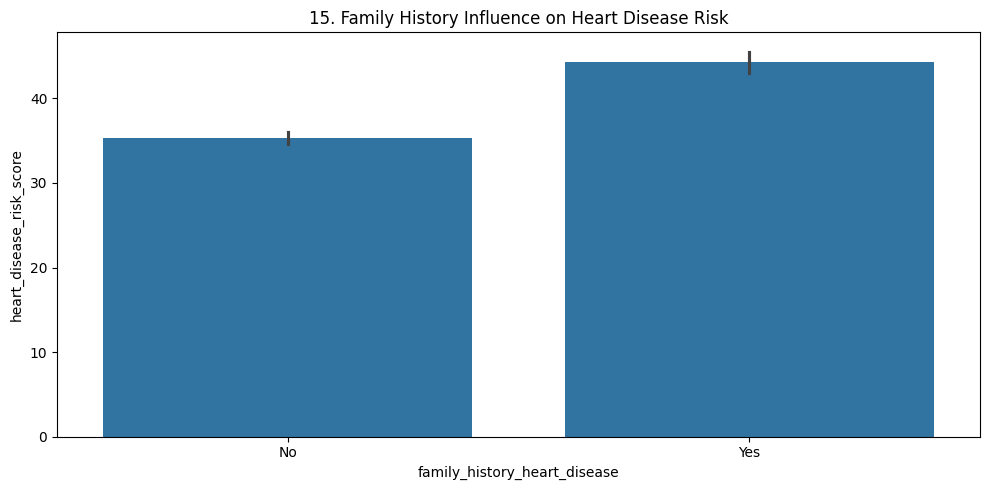

In [25]:
fig = plt.figure(figsize=(10,5))
sns.barplot(data=df, x='family_history_heart_disease', y='heart_disease_risk_score')
plt.title(f'{plot_no}. Family History Influence on Heart Disease Risk')
show_fig()
plot_no += 1

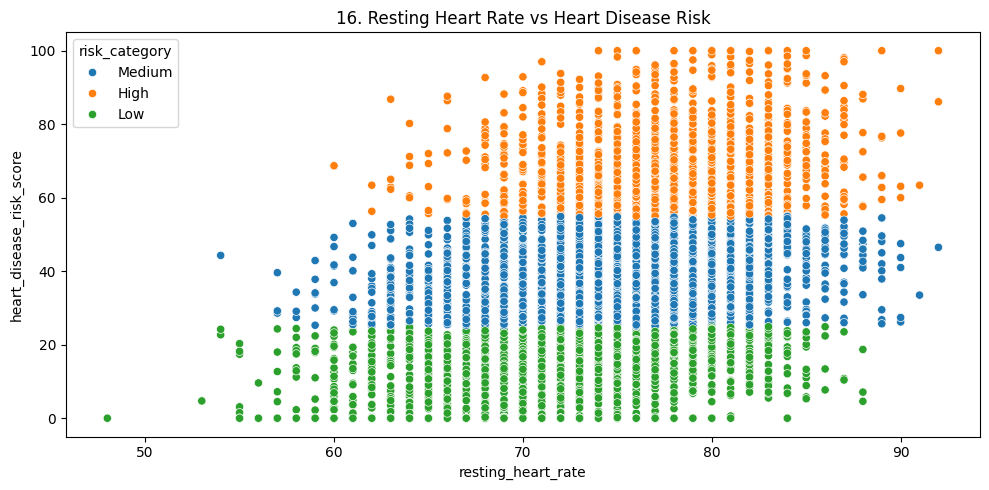

In [26]:
fig = plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='resting_heart_rate', y='heart_disease_risk_score', hue='risk_category')
plt.title(f'{plot_no}. Resting Heart Rate vs Heart Disease Risk')
show_fig()
plot_no += 1

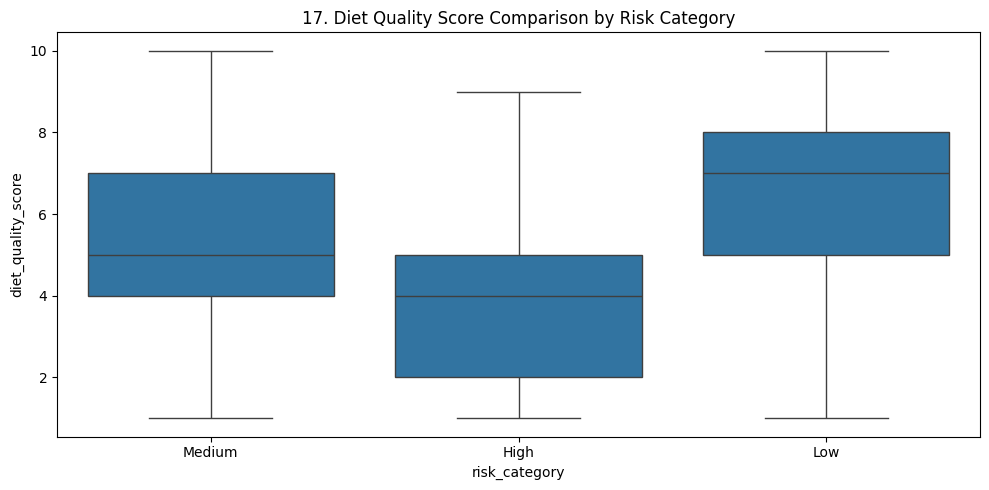

In [27]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='risk_category', y='diet_quality_score')
plt.title(f'{plot_no}. Diet Quality Score Comparison by Risk Category')
show_fig()
plot_no += 1

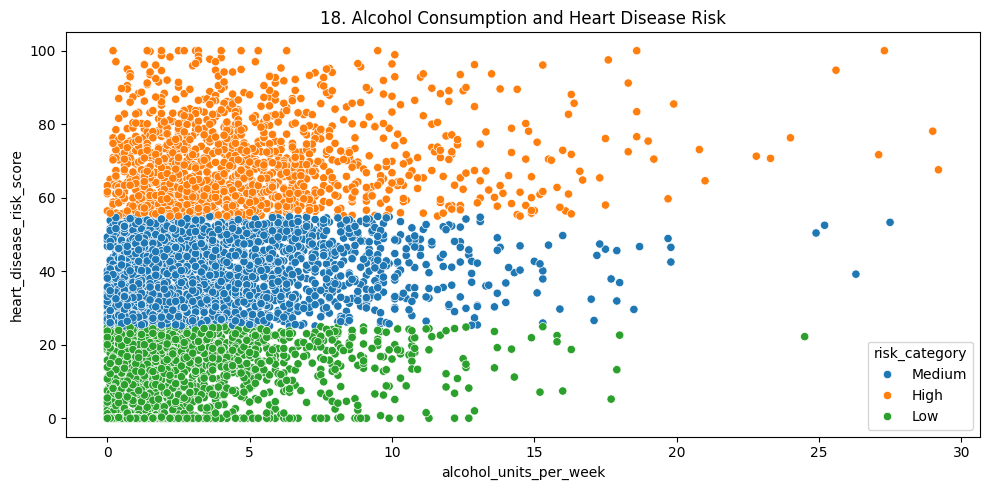

In [28]:
fig = plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='alcohol_units_per_week', y='heart_disease_risk_score', hue='risk_category')
plt.title(f'{plot_no}. Alcohol Consumption and Heart Disease Risk')
show_fig()
plot_no += 1


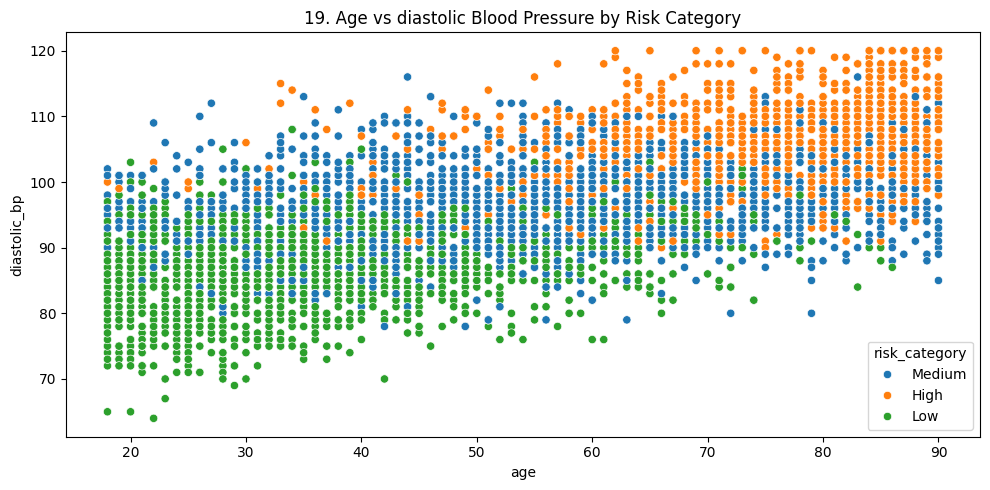

In [29]:
fig = plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='age', y='diastolic_bp', hue='risk_category')
plt.title(f'{plot_no}. Age vs diastolic Blood Pressure by Risk Category')
show_fig()
plot_no += 1

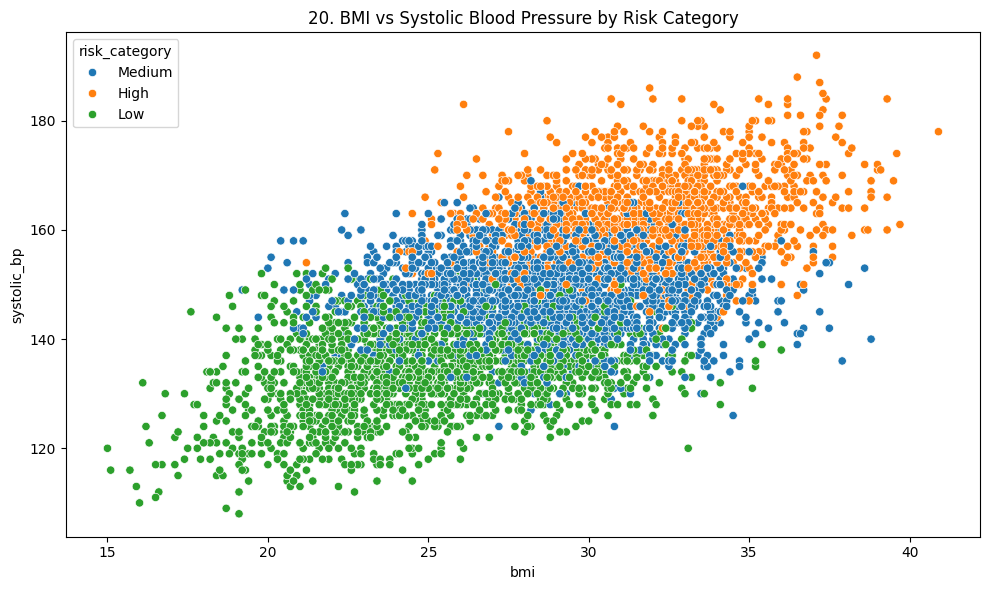

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='bmi', y='systolic_bp', hue='risk_category')
plt.title(f'{plot_no}. BMI vs Systolic Blood Pressure by Risk Category')
show_fig()
plot_no += 1

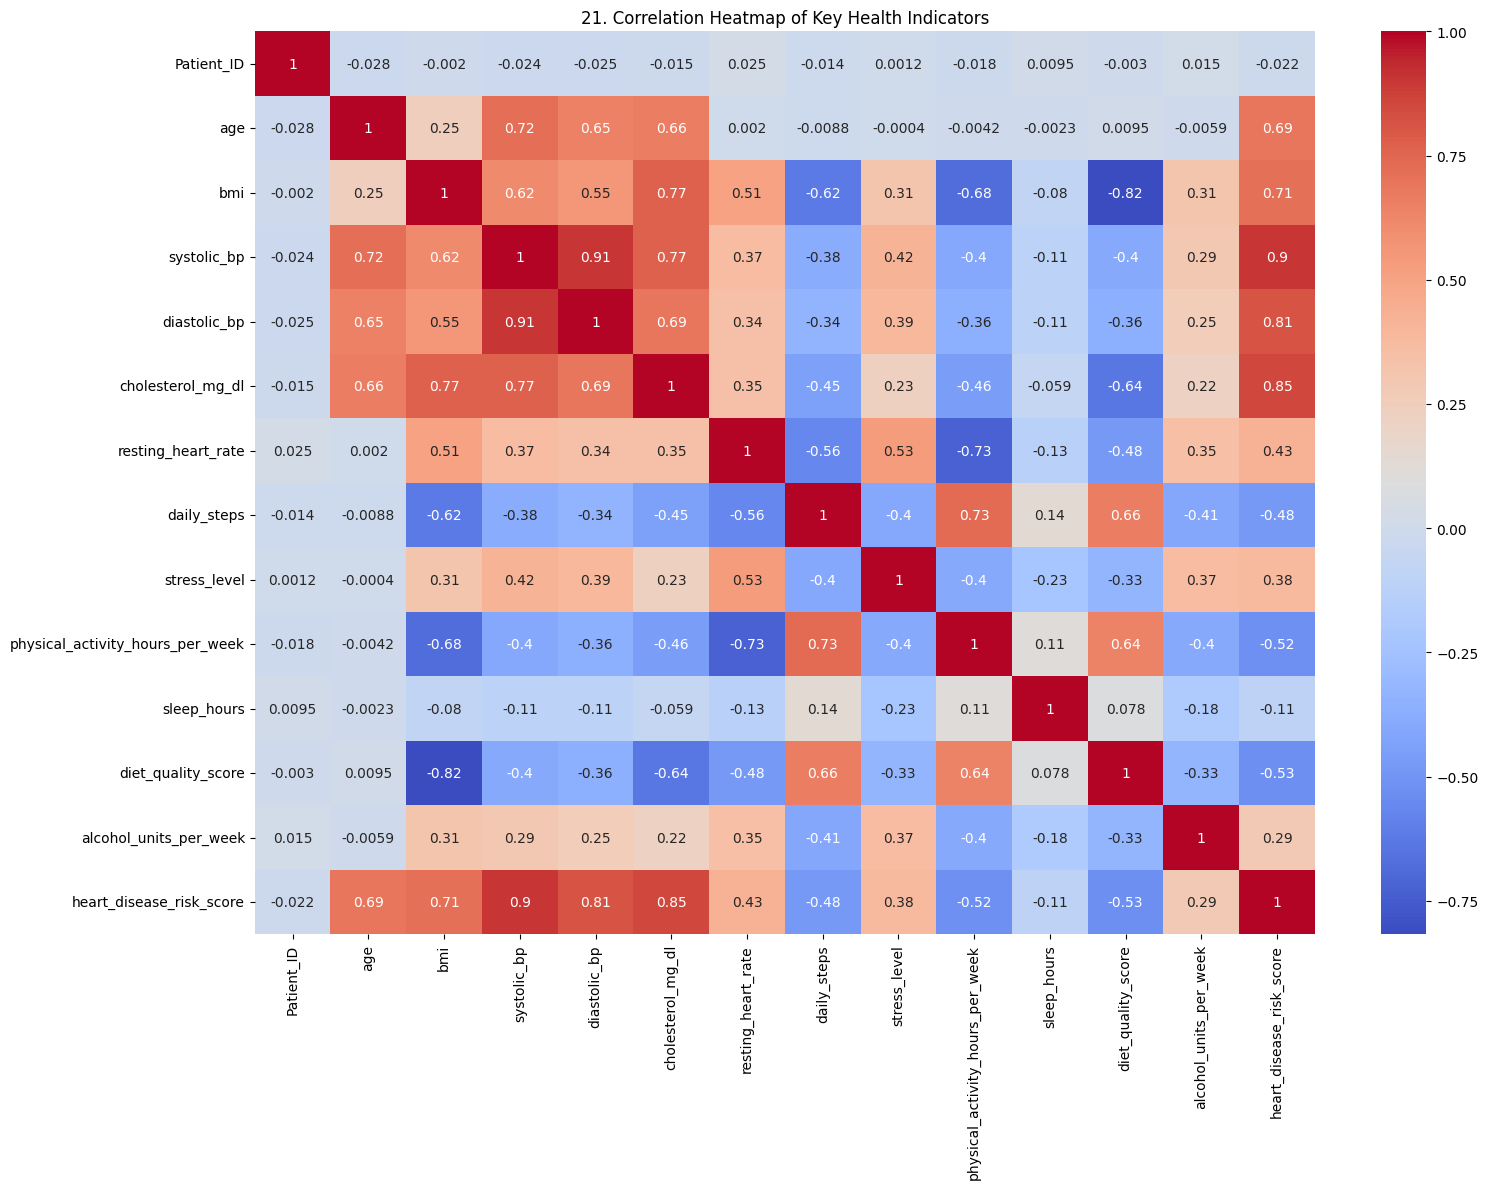

In [31]:
fig = plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Key Health Indicators')
show_fig()
plot_no += 1

TRAINING

In [62]:

X = df.drop("risk_category", axis=1)
y = df["risk_category"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [66]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)


In [67]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [69]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Make predictions

In [70]:
y_pred = model.predict(X_test_scaled)

In [ ]:
accuracy_score

In [71]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9764


Confusion matrix

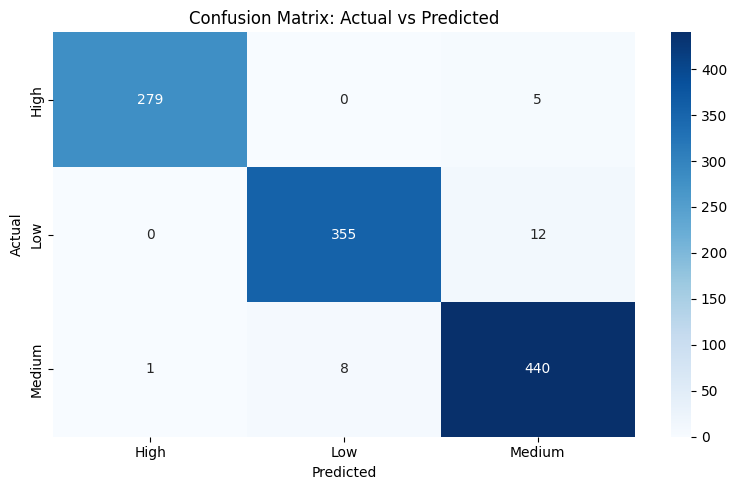

In [73]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.title('Confusion Matrix: Actual vs Predicted')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


Classification Report

In [74]:
from sklearn.metrics import classification_report
clr = classification_report(y_test , y_pred)
print("DECISION TREE CLASSIFIER REPORT")
print(clr)

DECISION TREE CLASSIFIER REPORT
              precision    recall  f1-score   support

        High       1.00      0.98      0.99       284
         Low       0.98      0.97      0.97       367
      Medium       0.96      0.98      0.97       449

    accuracy                           0.98      1100
   macro avg       0.98      0.98      0.98      1100
weighted avg       0.98      0.98      0.98      1100



In [76]:
from sklearn.metrics import classification_report
clrr = classification_report(y_test , y_pred)
print("RANDOM FOREST CLASSIFIER REPORT")

print(clrr)

RANDOM FOREST CLASSIFIER REPORT
              precision    recall  f1-score   support

        High       1.00      0.98      0.99       284
         Low       0.98      0.97      0.97       367
      Medium       0.96      0.98      0.97       449

    accuracy                           0.98      1100
   macro avg       0.98      0.98      0.98      1100
weighted avg       0.98      0.98      0.98      1100



In [77]:
joblib.dump(clr, 'drug_model.joblib')

print("Model saved successfully as drug_model.joblib")

Model saved successfully as drug_model.joblib
